In [ ]:
!pip install -U ultralytics

In [ ]:
import ultralytics
print(ultralytics.__version__)

8.4.75


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import glob
import random
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

import IPython.display as display
from PIL import Image
import cv2
ff
from ultralytics import YOLO

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehilsanyal/construction-site-safety-image-dataset-roboflow")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'construction-site-safety-image-dataset-roboflow' dataset.
Path to dataset files: /kaggle/input/construction-site-safety-image-dataset-roboflow


In [ ]:
class CFG:
    """
    Configuration class for YOLOv8 PPE detection training.

    This class centralizes all training parameters including hyperparameters,
    dataset configuration, and output paths for organized experimentation.
    """

    # ===== DEBUG & REPRODUCIBILITY =====
    DEBUG = True                       # Set True for quick experiments with 10% data
    FRACTION = 0.10 if DEBUG else 1.0  # Data fraction to use (1.0 = 100%)
    SEED = 88                           # Random seed for reproducibility

    # ===== CLASS DEFINITIONS =====
    # 10 PPE-related object classes for construction site monitoring
    CLASSES = ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
               'NO-Safety Vest', 'Person', 'Safety Cone',
               'Safety Vest', 'machinery', 'vehicle']
    NUM_CLASSES_TO_TRAIN = len(CLASSES)  # Automatically computed: 10 classes

    # ===== TRAINING HYPERPARAMETERS =====
    EPOCHS = 100        # Total training epochs (200 for production, 3 for debug)
    BATCH_SIZE = 16                     # Batch size per training step

    # Model selection and initialization
    BASE_MODEL = 'yolov8s'              # Small variant: yolov8n, yolov8s, yolov8m, yolov8l, yolov8x
    BASE_MODEL_WEIGHTS = f'{BASE_MODEL}.pt'  # Pre-trained weights file
    EXP_NAME = f'ppe_css_{EPOCHS}_epochs'    # Experiment identifier for output naming

    # ===== OPTIMIZER & LEARNING RATE =====
    OPTIMIZER = 'auto'                 # Options: SGD, Adam, Adamax, AdamW, NAdam, RAdam, RMSProp, auto
    LR = 1e-3                           # Initial learning rate (0.001)
    LR_FACTOR = 0.01                    # Learning rate decay factor (100x reduction at end)
    WEIGHT_DECAY = 5e-4                 # L2 regularization parameter
    DROPOUT = 0.025                     # Dropout probability for regularization
    PATIENCE = 25                       # Early stopping patience (epochs without improvement)
    PROFILE = False                     # Enable profiling for performance analysis
    LABEL_SMOOTHING = 0.0               # Label smoothing for classification loss

    # ===== DATA PATHS =====
    CUSTOM_DATASET_DIR = '/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data'    # Root dataset directory (train/valid/test subdirs)
    OUTPUT_DIR = '/kaggle/Output_folder'          # Output directory for training results and models

In [ ]:
# Create data.yaml configuration dictionary
dict_file = {
    'train': f'.{CFG.CUSTOM_DATASET_DIR}/train',    # Path to training images and labels
    'val': f'.{CFG.CUSTOM_DATASET_DIR}/valid',      # Path to validation images and labels
    'test': f'.{CFG.CUSTOM_DATASET_DIR}/test',      # Path to test images and labels
    'nc': CFG.NUM_CLASSES_TO_TRAIN,                 # Number of classes (10)
    'names': CFG.CLASSES                            # Class name mapping
}

# Write YAML file that will be consumed by YOLOv8
with open(os.path.join(CFG.OUTPUT_DIR, 'data.yaml'), 'w+') as file:
    yaml.dump(dict_file, file)

In [ ]:
# ===== UTILITY FUNCTIONS FOR YAML HANDLING =====

def read_yaml_file(file_path=CFG.CUSTOM_DATASET_DIR):
    """
    Load and parse YAML configuration file.

    Parameters:
    -----------
    file_path : str
        Path to the YAML file to read

    Returns:
    --------
    dict or None
        Parsed YAML data as dictionary, or None if parsing fails
    """
    with open(file_path, 'r') as file:
        try:
            data = yaml.safe_load(file)
            return data
        except yaml.YAMLError as e:
            print("Error reading YAML:", e)
            return None


def print_yaml_data(data):
    """
    Pretty-print YAML data with newline formatting for readability.

    Parameters:
    -----------
    data : dict
        Dictionary to format and print as YAML
    """
    formatted_yaml = yaml.dump(data, default_style=False)
    print(formatted_yaml)


# Load and display the configuration
file_path = os.path.join(CFG.OUTPUT_DIR, 'data.yaml')
yaml_data = read_yaml_file(file_path)

if yaml_data:
    print_yaml_data(yaml_data)

names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle
nc: 10
test: ./kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test
train: ./kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/train
val: ./kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid



In [ ]:
def display_image(image, print_info=True, hide_axis=False):
    """
    Display a single image with optional metadata printing.

    Parameters:
    -----------
    image : str or np.ndarray
        Image file path (str) or image array (np.ndarray)
    print_info : bool, default=True
        Print image type, shape, and metadata
    hide_axis : bool, default=False
        Hide matplotlib axis for cleaner display

    Supports:
    ---------
    - File paths to JPG, PNG, etc.
    - NumPy arrays in BGR (OpenCV) or RGB format
    """
    if isinstance(image, str):  # File path provided
        img = Image.open(image)
        plt.imshow(img)
    elif isinstance(image, np.ndarray):  # NumPy array provided
        image = image[..., ::-1]  # Convert BGR (OpenCV) to RGB (PIL)
        img = Image.fromarray(image)
        plt.imshow(img)
    else:
        raise ValueError("Unsupported image format. Provide file path (str) or numpy array")

    if print_info:
        print('Type: ', type(img), '\n')
        print('Shape: ', np.array(img).shape, '\n')

    if hide_axis:
        plt.axis('off')

    plt.show()

In [ ]:
def plot_random_images_from_folder(folder_path, num_images=20, seed=CFG.SEED):
    """
    Display a grid of random images from a directory.

    Parameters:
    -----------
    folder_path : str
        Path to folder containing images
    num_images : int, default=20
        Number of images to display (arranged in 5-column grid)
    seed : int, default=CFG.SEED
        Random seed for reproducible selection

    Returns:
    --------
    None (displays matplotlib grid)
    """
    random.seed(seed)

    # Get list of all image files in the folder
    image_files = [f for f in os.listdir(folder_path)
                   if f.endswith(('.jpg', '.png', '.jpeg', '.gif'))]

    # Validate sufficient images available
    if len(image_files) < num_images:
        raise ValueError(f"Only {len(image_files)} images found, need {num_images}")

    # Randomly select images without replacement
    selected_files = random.sample(image_files, num_images)

    # Create subplot grid (5 columns, auto-computed rows)
    num_cols = 5
    num_rows = (num_images + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))

    for i, file_name in enumerate(selected_files):
        # Load image
        img = Image.open(os.path.join(folder_path, file_name))

        # Get correct axis reference
        if num_rows == 1:
            ax = axes[i % num_cols]
        else:
            ax = axes[i // num_cols, i % num_cols]

        ax.imshow(img)
        ax.axis('off')

    # Remove empty subplots
    for i in range(num_images, num_rows * num_cols):
        if num_rows == 1:
            fig.delaxes(axes[i % num_cols])
        else:
            fig.delaxes(axes[i // num_cols, i % num_cols])

    plt.tight_layout()
    plt.show()

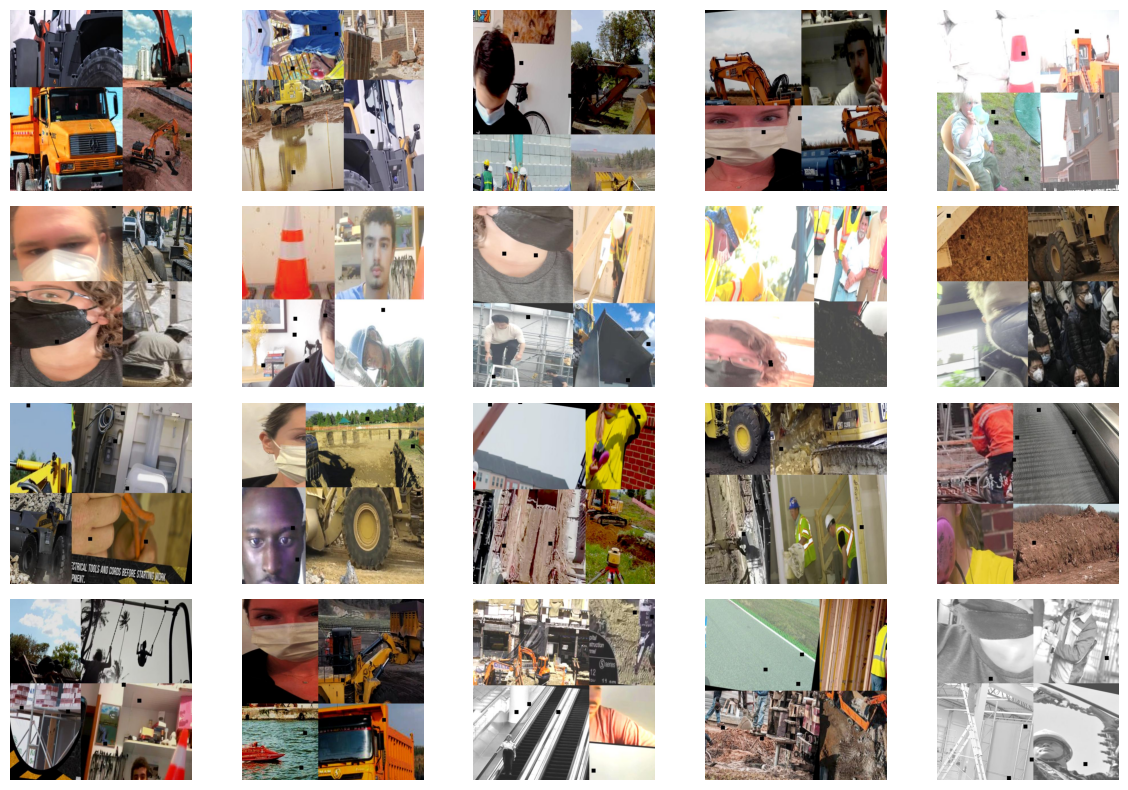

In [ ]:
folder_path = f'{CFG.CUSTOM_DATASET_DIR}/train/images/'
plot_random_images_from_folder(folder_path, num_images=20, seed=CFG.SEED)
# plot_random_images_from_folder(folder_path, num_images=20, seed=54)

In [ ]:
def get_image_properties(image_path):
    """
    Extract and return image metadata properties.

    Parameters:
    -----------
    image_path : str
        Path to image file

    Returns:
    --------
    dict
        Dictionary containing:
        - width: Image width in pixels
        - height: Image height in pixels
        - channels: Number of color channels (1=grayscale, 3=RGB/BGR)
        - dtype: Data type of pixel values (uint8, float32, etc.)

    Raises:
    -------
    ValueError
        If image file cannot be read
    """
    # Read image using OpenCV (BGR format)
    img = cv2.imread(image_path)

    # Validate image loading
    if img is None:
        raise ValueError(f"Could not read image file: {image_path}")

    # Extract properties
    properties = {
        "width": img.shape[1],                          # Image width
        "height": img.shape[0],                         # Image height
        "channels": img.shape[2] if len(img.shape) == 3 else 1,  # Color channels
        "dtype": img.dtype,                             # Data type (uint8)
    }

    return properties
img_properties = get_image_properties(example_image_path)
img_properties

{'width': 640, 'height': 640, 'channels': 3, 'dtype': dtype('uint8')}

In [ ]:
%%time

# ===== COUNT CLASS OCCURRENCES ACROSS ALL DATASET SPLITS =====
# Build mapping from class ID to class name
class_idx = {str(i): CFG.CLASSES[i] for i in range(CFG.NUM_CLASSES_TO_TRAIN)}

class_stat = {}        # Store class statistics per split
data_len = {}          # Store image count per split
class_info = []        # Collect data for DataFrame creation

# Process each dataset split (train, valid, test)
for mode in ['train', 'valid', 'test']:
    # Initialize counter for all classes
    class_count = {CFG.CLASSES[i]: 0 for i in range(CFG.NUM_CLASSES_TO_TRAIN)}

    # Path to label files for this split
    path = os.path.join("/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data", mode, 'labels')

    # Iterate through all label files
    for file in os.listdir(path):
        with open(os.path.join(path, file)) as f:
            lines = f.readlines()

            # Extract unique class IDs from this file and increment counters
            for cls in set([line[0] for line in lines]):
                class_count[class_idx[cls]] += 1

    # Store statistics
    data_len[mode] = len(os.listdir(path))                    # Number of images
    class_stat[mode] = class_count                            # Per-class detection counts
    class_info.append({'Mode': mode, **class_count, 'Data_Volume': data_len[mode]})

# Create summary DataFrame
dataset_stats_df = pd.DataFrame(class_info)
dataset_stats_df

CPU times: user 241 ms, sys: 126 ms, total: 367 ms
Wall time: 2.02 s


,Mode,Hardhat,Mask,NO-Hardhat,NO-Mask,NO-Safety Vest,Person,Safety Cone,Safety Vest,machinery,vehicle,Data_Volume
0,train,1314,1096,1380,1531,1864,2526,631,1319,2101,744,2605
1,valid,42,19,37,44,56,84,13,28,26,16,114
2,test,30,16,25,30,36,59,8,22,22,15,82


In [ ]:
CFG.BASE_MODEL_WEIGHTS

'yolo26s.pt'

In [ ]:
# ===== LOAD PRE-TRAINED YOLOV8 MODEL FOR BASELINE INFERENCE =====
model = YOLO(CFG.BASE_MODEL_WEIGHTS)

# Run inference on example image with specified parameters
results = model.predict(
    source=example_image_path,                           # Input image path
    classes=[0],                                         # Filter: detect only class 0 (Hardhat)
    conf=0.010,                                          # Confidence threshold (40%)                                         # GPU device ID (0 = first GPU)
    imgsz=(img_properties['height'], img_properties['width']),  # Input size

    # Output options
    save=True,                                          # Save result image
    save_txt=True,                                      # Save detections as text
    save_conf=True,                                     # Include confidence scores
    exist_ok=True,                                      # Overwrite existing outputs
)


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/train/images/-1670-_png_jpg.rf.7da967f9aeaa62defc36543b9e6000af.jpg: 640x640 6 persons, 29.5ms
Speed: 4.1ms preprocess, 29.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
2 labels saved to /content/runs/detect/predict/labels


In [ ]:
# ===== PRINT TRAINING CONFIGURATION =====
print('Model Architecture: ', CFG.BASE_MODEL_WEIGHTS)
print('Total Epochs: ', CFG.EPOCHS)
print('Batch Size: ', CFG.BATCH_SIZE)
print('Base Learning Rate: ', CFG.LR)
print('Number of Classes: ', CFG.NUM_CLASSES_TO_TRAIN)

Model Architecture:  yolo26s.pt
Total Epochs:  100
Batch Size:  16
Base Learning Rate:  0.001
Number of Classes:  10


In [ ]:
%%time

# ===== TRAIN YOLOV8 MODEL ON CUSTOM DATASET =====
model.train(
    # Dataset configuration
    data=os.path.join(CFG.OUTPUT_DIR, 'data.yaml'),      # Path to dataset YAML config
    task='detect',                                       # Task type: detect, segment, pose, classify

    # Input configuration
    imgsz=(img_properties['height'], img_properties['width']),  # Training image size

    # Training parameters
    epochs=CFG.EPOCHS,                                  # Number of epochs (200)
    batch=CFG.BATCH_SIZE,                               # Batch size per GPU (16)

    # Optimizer & learning rate
    optimizer=CFG.OPTIMIZER,                            # Optimizer algorithm (auto)
    lr0=CFG.LR,                                         # Initial learning rate (1e-3)
    lrf=CFG.LR_FACTOR,                                  # Final learning rate factor (0.01)

    # Regularization
    weight_decay=CFG.WEIGHT_DECAY,                      # L2 regularization (5e-4)
    dropout=CFG.DROPOUT,                                # Dropout probability (0.025)
    fraction=CFG.FRACTION,                              # Data fraction to use (1.0 = 100%)

    # Early stopping
    patience=CFG.PATIENCE,                              # Early stopping patience (25 epochs)

    # Debugging & profiling
    profile=CFG.PROFILE,                                # Enable profiling

    # Experiment identification
    name=f'{CFG.BASE_MODEL}_{CFG.EXP_NAME}',            # Experiment name
    seed=CFG.SEED,                                      # Random seed (88)

    # Validation & checkpointing
    val=True,                                           # Run validation each epoch
    amp=True,                                           # Automatic Mixed Precision (faster)
    exist_ok=True,                                      # Overwrite existing results
    resume=False,                                       # Don't resume from checkpoint

    # Hardware                                          # GPU device IDs to use
    verbose=False,                                      # Suppress verbose output
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/Output_folder/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.025, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.1, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=(640, 640), int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_ppe_css_100_epochs, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7edb3b1d0440>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [ ]:
# ===== LOAD PRE-TRAINED YOLOV8 MODEL FOR BASELINE INFERENCE =====
model = YOLO(CFG.BASE_MODEL_WEIGHTS)

# Run inference on example image with specified parameters
results = model.predict(
    source=example_image_path,                           # Input image path
    classes=[0],                                         # Filter: detect only class 0 (Hardhat)
    conf=0.010,                                          # Confidence threshold (40%)                                         # GPU device ID (0 = first GPU)
    imgsz=(img_properties['height'], img_properties['width']),  # Input size

    # Output options
    save=True,                                          # Save result image
    save_txt=True,                                      # Save detections as text
    save_conf=True,                                     # Include confidence scores
    exist_ok=True,                                      # Overwrite existing outputs
)


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/train/images/-1670-_png_jpg.rf.7da967f9aeaa62defc36543b9e6000af.jpg: 640x640 8 persons, 16.4ms
Speed: 2.2ms preprocess, 16.4ms inference, 10.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
2 labels saved to /content/runs/detect/predict/labels


In [ ]:
# ===== PRINT TRAINING CONFIGURATION =====
print('Model Architecture: ', CFG.BASE_MODEL_WEIGHTS)
print('Total Epochs: ', CFG.EPOCHS)
print('Batch Size: ', CFG.BATCH_SIZE)
print('Base Learning Rate: ', CFG.LR)
print('Number of Classes: ', CFG.NUM_CLASSES_TO_TRAIN)

Model Architecture:  yolov8s.pt
Total Epochs:  100
Batch Size:  16
Base Learning Rate:  0.001
Number of Classes:  10


In [ ]:
%%time

# ===== TRAIN YOLOV8 MODEL ON CUSTOM DATASET =====
model.train(
    # Dataset configuration
    data=os.path.join(CFG.OUTPUT_DIR, 'data.yaml'),      # Path to dataset YAML config
    task='detect',                                       # Task type: detect, segment, pose, classify

    # Input configuration
    imgsz=(img_properties['height'], img_properties['width']),  # Training image size

    # Training parameters
    epochs=CFG.EPOCHS,                                  # Number of epochs (200)
    batch=CFG.BATCH_SIZE,                               # Batch size per GPU (16)

    # Optimizer & learning rate
    optimizer=CFG.OPTIMIZER,                            # Optimizer algorithm (auto)
    lr0=CFG.LR,                                         # Initial learning rate (1e-3)
    lrf=CFG.LR_FACTOR,                                  # Final learning rate factor (0.01)

    # Regularization
    weight_decay=CFG.WEIGHT_DECAY,                      # L2 regularization (5e-4)
    dropout=CFG.DROPOUT,                                # Dropout probability (0.025)
    fraction=CFG.FRACTION,                              # Data fraction to use (1.0 = 100%)

    # Early stopping
    patience=CFG.PATIENCE,                              # Early stopping patience (25 epochs)

    # Debugging & profiling
    profile=CFG.PROFILE,                                # Enable profiling

    # Experiment identification
    name=f'{CFG.BASE_MODEL}_{CFG.EXP_NAME}',            # Experiment name
    seed=CFG.SEED,                                      # Random seed (88)

    # Validation & checkpointing
    val=True,                                           # Run validation each epoch
    amp=True,                                           # Automatic Mixed Precision (faster)
    exist_ok=True,                                      # Overwrite existing results
    resume=False,                                       # Don't resume from checkpoint

    # Hardware                                          # GPU device IDs to use
    verbose=False,                                      # Suppress verbose output
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/Output_folder/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.025, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.1, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=(640, 640), int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_ppe_css_100_epochs, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7edb4a61fd40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [ ]:
img_properties

{'width': 640, 'height': 640, 'channels': 3, 'dtype': dtype('uint8')}

In [ ]:
# ===== EXPORT TRAINED MODEL TO ONNX FORMAT =====
# ONNX (Open Neural Network Exchange) enables cross-platform inference
# Compatible with CPU inference engines (ORT, TensorRT) and mobile platforms
model.export(
    format='onnx',                                              # Export format
    imgsz=(img_properties['height'], img_properties['width']),  # Model input size
    half=False,                                                 # No FP16 conversion
    int8=False,                                                 # No INT8 quantization
    simplify=False,                                             # No graph simplification
    nms=False,                                                  # Keep NMS in model
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs

PyTorch: starting from '/content/runs/detect/yolov8s_ppe_css_100_epochs/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (21.5 MB)
requirements: Ultralytics requirement ['onnx>=1.12.0,<2.0.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 5 packages in 288ms
Prepared 1 package in 2.09s
Installed 1 package in 1.12s
 + onnx==1.22.0

requirements: AutoUpdate success ✅ 4.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: export success ✅ 6.4s, saved as '/content/runs/detect/yolov8s_ppe_css_100_epochs/weights/b

'/content/runs/detect/yolov8s_ppe_css_100_epochs/weights/best.onnx'

In [ ]:
# Export to TFLite
model.export(
    format='tflite',
    imgsz=(img_properties['height'], img_properties['width']),
    half=False,
    int8=False
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs

PyTorch: starting from '/content/runs/detect/yolov8s_ppe_css_100_epochs/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 361ms
Prepared 3 packages in 565ms
Installed 3 packages in 17ms
 + colorama==0.4.6
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 11.4s, saved as '/content/runs/detect/yolov8s_ppe_css_100_epochs/weights/best.onnx' (42.8 MB)
requirements: Ultraly

'/content/runs/detect/yolov8s_ppe_css_100_epochs/weights/best_saved_model/best_float32.tflite'

In [ ]:
import glob

results_paths = [
    i for i in
    glob.glob(f'/content/runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/*.png') +
    glob.glob(f'/content/runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/*.jpg')
    if 'batch' not in i
]

print(results_paths)

['/content/runs/detect/yolov8s_ppe_css_100_epochs/BoxP_curve.png', '/content/runs/detect/yolov8s_ppe_css_100_epochs/results.png', '/content/runs/detect/yolov8s_ppe_css_100_epochs/BoxPR_curve.png', '/content/runs/detect/yolov8s_ppe_css_100_epochs/BoxF1_curve.png', '/content/runs/detect/yolov8s_ppe_css_100_epochs/BoxR_curve.png', '/content/runs/detect/yolov8s_ppe_css_100_epochs/confusion_matrix_normalized.png', '/content/runs/detect/yolov8s_ppe_css_100_epochs/confusion_matrix.png', '/content/runs/detect/yolov8s_ppe_css_100_epochs/labels.jpg']


/content/runs/detect/yolov8s_ppe_css_100_epochs/BoxF1_curve.png


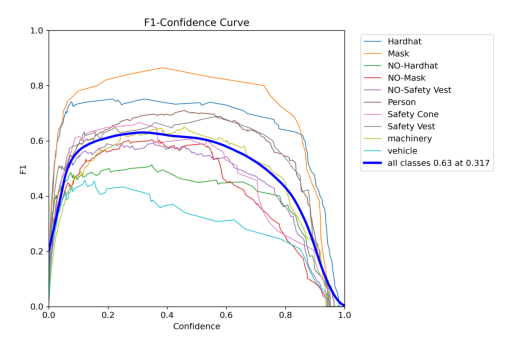



/content/runs/detect/yolov8s_ppe_css_100_epochs/BoxPR_curve.png


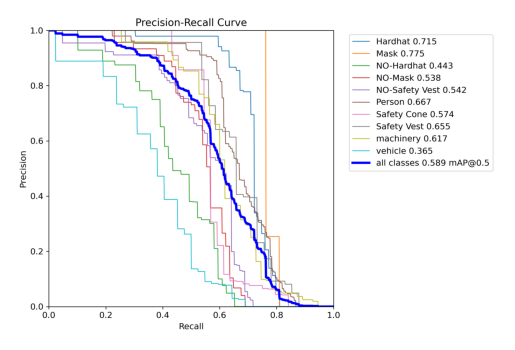



/content/runs/detect/yolov8s_ppe_css_100_epochs/BoxP_curve.png


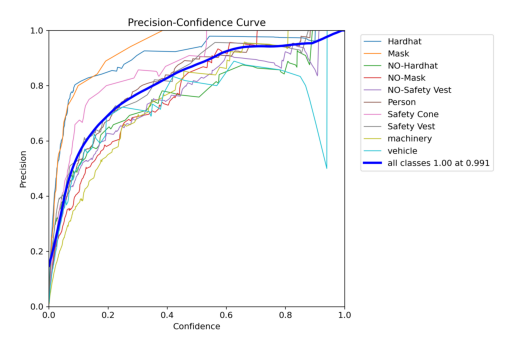



/content/runs/detect/yolov8s_ppe_css_100_epochs/BoxR_curve.png


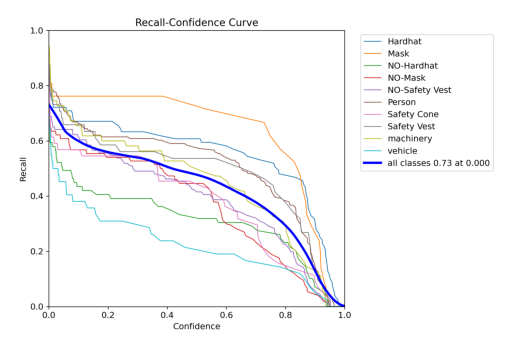



/content/runs/detect/yolov8s_ppe_css_100_epochs/confusion_matrix.png


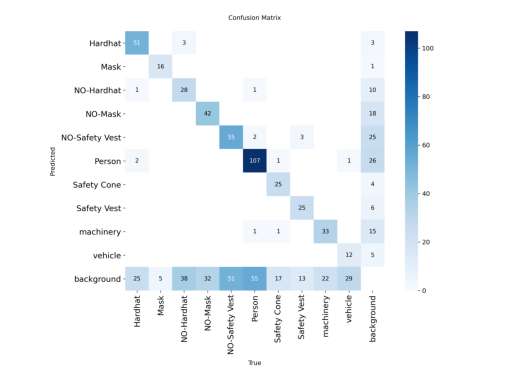



/content/runs/detect/yolov8s_ppe_css_100_epochs/confusion_matrix_normalized.png


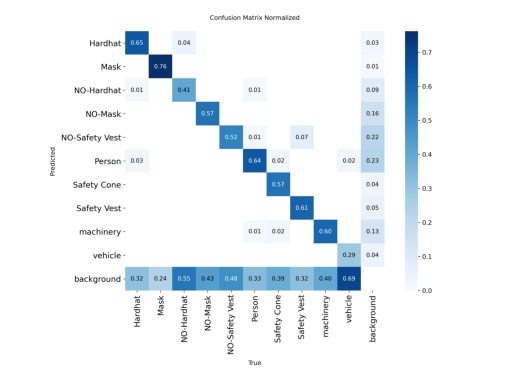



/content/runs/detect/yolov8s_ppe_css_100_epochs/labels.jpg


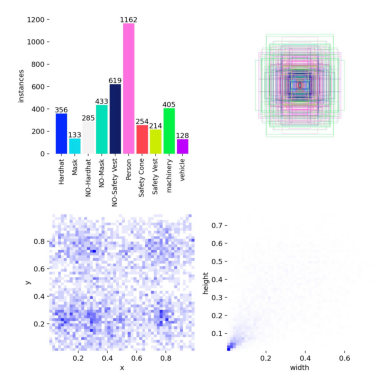



/content/runs/detect/yolov8s_ppe_css_100_epochs/results.png


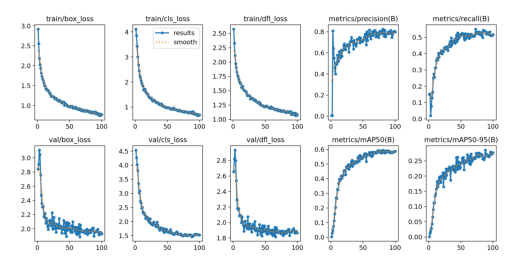

In [ ]:
for file in sorted(results_paths):
    print(file)
    display_image(file, print_info = False, hide_axis = True)
    print('\n')

In [ ]:
# ===== LOCATE VALIDATION BATCH VISUALIZATIONS =====
# YOLOv8 training generates validation batch images showing ground truth and predictions
# These images contain visualizations of model performance on validation data

validation_results_paths = [
    i for i in
    glob.glob(f'/content/runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/*.png') +
    glob.glob(f'/content/runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/*.jpg')
    if 'val_batch' in i  # Filter for validation batch images
]

print(f'Found {len(validation_results_paths)} validation batch visualizations')

Found 6 validation batch visualizations


In [ ]:
if len(validation_results_paths) >= 1:
    print(validation_results_paths[-1])

/content/runs/detect/yolov8s_ppe_css_100_epochs/val_batch1_pred.jpg


Validation Batch Visualization: /content/runs/detect/yolov8s_ppe_css_100_epochs/val_batch1_labels.jpg

This image shows:
- Green bounding boxes: Correct predictions by model
- Red bounding boxes: Incorrect predictions (false positives)
- Yellow bounding boxes: Missed detections (false negatives)


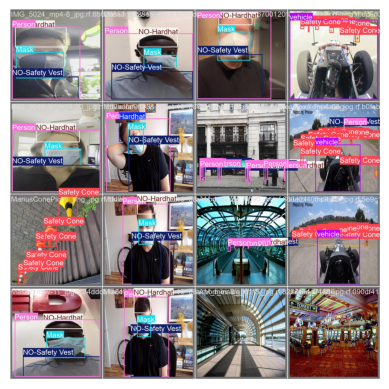

In [ ]:
# ===== DISPLAY RANDOM VALIDATION BATCH VISUALIZATION =====
# Shows model predictions on unseen validation images during training
# Useful for qualitative assessment of detection quality

if len(validation_results_paths) >= 1:
    # Randomly select one validation batch visualization
    val_img_path = random.choice(validation_results_paths)
    print(f'Validation Batch Visualization: {val_img_path}')
    print('\nThis image shows:')
    print('- Green bounding boxes: Correct predictions by model')
    print('- Red bounding boxes: Incorrect predictions (false positives)')
    print('- Yellow bounding boxes: Missed detections (false negatives)')
    display_image(val_img_path, print_info=False, hide_axis=True)